### Determinar área de estudio

In [10]:
import geopandas as gpd
from shapely.geometry import Polygon, LineString, box
from matplotlib.colors import ListedColormap
from shapely.ops import polygonize, unary_union
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
target_crs = "EPSG:4326"
available_fishing_area = gpd.read_file("./data/available_SWA_fishing_area.geojson")
available_fishing_area = available_fishing_area.to_crs(target_crs)

eez = gpd.read_file("./resources/Marine_Regions/World_EEZ_v12/eez_v12.shp")
eez = eez.to_crs(target_crs)
eez_fk = eez[eez["GEONAME"].str.contains("Falkland", case=False, na=False)]
eez_arg = eez[eez["GEONAME"].str.contains("Argentin", case=False, na=False)]
p_fk_north=eez_fk.total_bounds[3]

VMEs = gpd.read_file("../../ARVI-IEO/IEO/RECURSOS/VMEs_ATSW/Categoria_VMEs/Areas_Categoria_VMEs.shp")
VME1 = VMEs[(VMEs["ID_area"] == 3) & (VMEs["Label"] == 1)]
VME1 = VME1.to_crs(target_crs)

fishing = xr.open_dataset("./data/processed/targets/HKP_0.1.nc")
mask = xr.open_dataset("./data/processed/static/fishing_area_mask_0.1.nc")
area_pesca = xr.open_dataset("./data/processed/static/area_pesca_0.1.nc")


In [4]:
west_geom = unary_union(available_fishing_area.geometry)
east_geom = unary_union(VME1.geometry)

# Use polygon boundaries if polygons
west_boundary = west_geom.boundary
east_boundary = east_geom.boundary

# -----------------------------
# Latitude limits
# -----------------------------
south_lat = p_fk_north
north_lat = -40
# -----------------------------------
# Get overall longitude extent
# (large enough to cross both boundaries)
# -----------------------------------
minx = min(west_geom.bounds[0], east_geom.bounds[0]) - 10
maxx = max(west_geom.bounds[2], east_geom.bounds[2]) + 10

# -----------------------------------
# Create horizontal latitude lines
# -----------------------------------
south_line = LineString([
    (minx, south_lat),
    (maxx, south_lat)])

north_line = LineString([
    (minx, north_lat),
    (maxx, north_lat)])

# -----------------------------------
# Merge all lines together
# -----------------------------------
all_lines = unary_union([
    west_boundary,
    east_boundary,
    south_line,
    north_line])

# -----------------------------------
# Polygonize closed regions
# -----------------------------------
polygons = list(polygonize(all_lines))

# -----------------------------------
# Convert to GeoDataFrame
# -----------------------------------
gdf_polys = gpd.GeoDataFrame(
    geometry=polygons,
    crs=target_crs)

# -----------------------------------
# OPTIONAL:
# Keep only polygons between the latitudes
# -----------------------------------
lat_box = Polygon([
    (minx, south_lat),
    (maxx, south_lat),
    (maxx, north_lat),
    (minx, north_lat)
])

gdf_polys = gdf_polys[gdf_polys.intersects(lat_box)]




In [5]:
study_area = gdf_polys.iloc[[1]]
study_area_m = study_area.to_crs("EPSG:3857")
cleaned = study_area_m.buffer(-2000).buffer(2000)
poly = cleaned.iloc[0].geoms[0]


cleaned = gpd.GeoSeries([poly], crs="EPSG:3857")
cleaned = cleaned.to_crs(target_crs)
minx, southest_lat, maxx, northest_lat = cleaned.iloc[0].bounds
lat_box = box(minx, southest_lat, maxx,northest_lat)
limited_geom = study_area.geometry.iloc[0].intersection(lat_box)
limited_gdf = gpd.GeoDataFrame(
    geometry=[limited_geom],
    crs=target_crs)



min_lon, min_lat, max_lon, max_lat = limited_gdf.total_bounds
step = 0.125
min_lon = (round(min_lon / step) * step)-0*step
min_lat = (round(min_lat / step) * step)-1*step
max_lon = (round(max_lon / step) * step)+0*step
max_lat = (round(max_lat / step) * step)+0*step
print(f"Bounding box: [{min_lon}, {min_lat}, {max_lon}, {max_lat}]")


Bounding box: [-61.0, -47.5, -60.0, -44.875]


In [6]:
# Guardar para crear las mascaras
buffer_010 = limited_gdf.copy()
buffer_010['geometry'] = limited_gdf.geometry.buffer(0.1)
# buffer_010.to_file("./data/area_pesca_0.1.geojson", driver="GeoJSON")

# 2. Create and save the 0.125 degree buffer
buffer_0125 = limited_gdf.copy()
buffer_0125['geometry'] = limited_gdf.geometry.buffer(0.125)
# buffer_0125.to_file("./data/area_pesca_0.125.geojson", driver="GeoJSON")

C:\Users\rubar\AppData\Local\Temp\ipykernel_9480\1906615499.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_010['geometry'] = limited_gdf.geometry.buffer(0.1)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9480\1906615499.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_0125['geometry'] = limited_gdf.geometry.buffer(0.125)


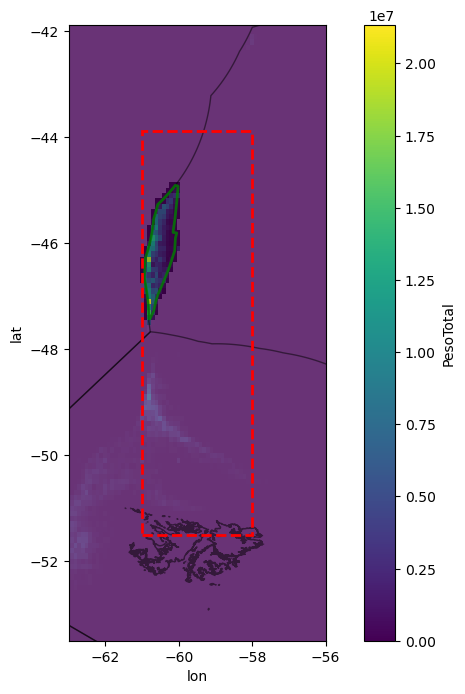

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

# Fishing raster
fishing["PesoTotal"].sum(dim="time").plot(
    ax=ax,
    cmap="viridis"
)

area_pesca["mask"].plot(
    ax=ax,
    add_colorbar=False,
    cmap="Grays",
    alpha=0.2
)

eez_arg.plot(
    ax=ax,
    alpha=0.5,
    facecolor="none",
)

# MVE polygon
limited_gdf = limited_gdf.to_crs("EPSG:4326")

limited_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="green",
    linewidth=2,
    alpha=0.8
)

# Define rectangle parameters
x0 = min_lon - 0
y0 = min_lat - 4
width  = (max_lon + 2) - (min_lon - 0)   # = max_lon - min_lon + 2.5
height = (max_lat + 1) - (min_lat - 4)    # = max_lat - min_lat + 5

# Create and add the rectangle
rect = Rectangle(
    (x0, y0), width, height,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
)
ax.add_patch(rect)
# Apply limits to the entire axes
ax.set_xlim(min_lon-2, max_lon+4)
ax.set_ylim(min_lat-6, max_lat+3)

plt.show()
